# Final predictions error analysis
This notebook analyses the final hold-out predictions exported by the training runs.
It loads the per-case prediction CSVs and the summary CSVs, compares stored test metrics with recomputed metrics, and visualizes errors.

## 1. Imports

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.style.use('default')

## 2. Helpers

In [2]:
DATA_DIR = Path('../results/')

def find_files(patterns, root=DATA_DIR):
    files = []
    for pattern in patterns:
        files.extend(sorted(root.glob(pattern)))
    seen, uniq = set(), []
    for f in files:
        if f not in seen:
            uniq.append(f)
            seen.add(f)
    return uniq

def infer_case_from_filename(name: str):
    s = name.lower()
    model = 'xgboost' if 'xgboost' in s else 'lightgbm' if 'lightgbm' in s else None
    m = re.search(r'(pohang|seoul)_to_(pohang|seoul)', s)
    origin = m.group(1) if m else None
    destination = m.group(2) if m else None

    if re.search(r'(^|[_\-.])d\+7($|[_\-.])', s):
        horizon = 'd+7'
    elif re.search(r'(^|[_\-.])d\+3($|[_\-.])', s):
        horizon = 'd+3'
    elif re.search(r'(^|[_\-.])d\+1($|[_\-.])', s):
        horizon = 'd+1'
    elif re.search(r'(^|[_\-.])d($|[_\-.])', s):
        horizon = 'd'
    else:
        horizon = None

    return model, origin, destination, horizon

def load_csvs(paths):
    frames = []
    loaded = []
    for p in paths:
        try:
            df = pd.read_csv(p)
            df['source_file'] = p.name
            model, origin, destination, horizon = infer_case_from_filename(p.name)

            if 'model' not in df.columns:
                df['model'] = model
            if 'origin' not in df.columns:
                df['origin'] = origin
            if 'destination' not in df.columns:
                df['destination'] = destination
            if 'horizon' not in df.columns:
                df['horizon'] = horizon
            if 'horizon_days' not in df.columns and horizon in {'d', 'd+1', 'd+3', 'd+7'}:
                df['horizon_days'] = {'d': 0, 'd+1': 1, 'd+3': 3, 'd+7': 7}[horizon]
            
            df.drop(columns='horizon', inplace=True)
            frames.append(df)
            loaded.append(p.name)
        except Exception as e:
            print(f'Skipping {p}: {e}')
    return frames, loaded

def safe_concat(frames):
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def normalize_summary(df):
    out = df.copy()
    ren = {}
    if 'mae_test' in out.columns: ren['mae_test'] = 'test_mae'
    if 'rmse_test' in out.columns: ren['rmse_test'] = 'test_rmse'
    if 'r2_test' in out.columns: ren['r2_test'] = 'test_r2'
    return out.rename(columns=ren)

def metrics_from_predictions(df):
    yt = pd.to_numeric(df['y_true'], errors='coerce').to_numpy()
    yp = pd.to_numeric(df['y_pred'], errors='coerce').to_numpy()
    m = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[m], yp[m]
    res = yt - yp
    mae = np.mean(np.abs(res))
    rmse = np.sqrt(np.mean(res**2))
    ss_res = np.sum(res**2)
    ss_tot = np.sum((yt - yt.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan
    bias = np.mean(res)
    return pd.Series({'mae': mae, 'rmse': rmse, 'r2': r2, 'bias': bias, 'n': len(yt)})

## 3. Load CSVs

In [12]:
summary_patterns = ['**/model_comparison_*_shap_top_20.csv', '**/model_comparison_*_shap_top_*.csv']
prediction_patterns = [
    '**/final_predictions/*.csv',
    '**/final_test_predictions/*.csv',
    '**/*_predictions.csv',
    '**/recreated_predictions/*.csv',
]

summary_files = find_files(summary_patterns)
prediction_files = find_files(prediction_patterns)

print('Summary files:')
for f in summary_files: print(' -', f)
print('\nPrediction files:')
for f in prediction_files: print(' -', f)

summary_frames, summary_loaded = load_csvs(summary_files)
pred_frames, pred_loaded = load_csvs(prediction_files)

summary_df = safe_concat(summary_frames)
pred_df = safe_concat(pred_frames)

print('\nLoaded summary files:', summary_loaded)
print('Loaded prediction files:', pred_loaded)
print('summary_df shape:', summary_df.shape)
print('pred_df shape:', pred_df.shape)

summary_df = normalize_summary(summary_df)

if not pred_df.empty:
    pred_df['y_true'] = pd.to_numeric(pred_df['y_true'], errors='coerce')
    pred_df['y_pred'] = pd.to_numeric(pred_df['y_pred'], errors='coerce')
    if 'error' not in pred_df.columns:
        pred_df['error'] = pred_df['y_pred'] - pred_df['y_true']
    if 'abs_error' not in pred_df.columns:
        pred_df['abs_error'] = pred_df['error'].abs()
    pred_df['residual'] = pred_df['y_true'] - pred_df['y_pred']
    pred_df['model'] = pred_df['model'].astype(str).str.lower()
    pred_df['origin'] = pred_df['origin'].astype(str).str.lower()
    pred_df['destination'] = pred_df['destination'].astype(str).str.lower()

    pred_df = pred_df.sort_values(['model', 'origin', 'destination', 'horizon_days']).reset_index(drop=True)

display(summary_df.head())
display(pred_df.head())

Summary files:
 - ../results/model_comparison_lightgbm_shap_top_20.csv
 - ../results/model_comparison_xgboost_shap_top_20.csv

Prediction files:
 - ../results/final_test_predictions/lightgbm_pohang_to_seoul_d+1.csv
 - ../results/final_test_predictions/lightgbm_pohang_to_seoul_d+3.csv
 - ../results/final_test_predictions/lightgbm_pohang_to_seoul_d+7.csv
 - ../results/final_test_predictions/lightgbm_pohang_to_seoul_d.csv
 - ../results/final_test_predictions/lightgbm_seoul_to_pohang_d+1.csv
 - ../results/final_test_predictions/lightgbm_seoul_to_pohang_d+3.csv
 - ../results/final_test_predictions/lightgbm_seoul_to_pohang_d+7.csv
 - ../results/final_test_predictions/lightgbm_seoul_to_pohang_d.csv
 - ../results/final_test_predictions/xgboost_pohang_to_seoul_d+1.csv
 - ../results/final_test_predictions/xgboost_pohang_to_seoul_d+3.csv
 - ../results/final_test_predictions/xgboost_pohang_to_seoul_d+7.csv
 - ../results/final_test_predictions/xgboost_pohang_to_seoul_d.csv
 - ../results/final_test_

,origin,destination,horizon_days,n_features_selected,mae_full,rmse_full,r2_full,mae_shap,rmse_shap,r2_shap,best_trial_number,mae_best,rmse_best,r2_best,n_trials,test_mae,test_rmse,test_r2,source_file,model
0,pohang,seoul,0,20,293.512068,434.196578,0.315408,293.068968,431.764760,0.322644,43,277.051160,414.209230,0.376514,50,168.652849,305.429023,0.635885,model_comparison_lightgbm_shap_top_20.csv,lightgbm
1,pohang,seoul,1,20,298.801200,438.926410,0.299679,285.288972,415.730256,0.371591,45,271.869184,403.481414,0.407434,50,164.464176,301.337917,0.645574,model_comparison_lightgbm_shap_top_20.csv,lightgbm
2,pohang,seoul,3,20,305.174631,448.688790,0.268209,283.240671,410.807661,0.386849,36,265.887409,395.151476,0.430892,50,173.515910,305.954322,0.634632,model_comparison_lightgbm_shap_top_20.csv,lightgbm
3,pohang,seoul,7,20,311.746495,452.926439,0.252639,291.100607,421.711909,0.355219,49,279.090730,415.799574,0.371265,50,169.257261,323.055806,0.592645,model_comparison_lightgbm_shap_top_20.csv,lightgbm
4,seoul,pohang,0,20,286.661504,429.648896,0.395402,285.387134,428.870118,0.398752,35,273.877692,424.263365,0.408868,50,175.188377,298.046512,0.637097,model_comparison_lightgbm_shap_top_20.csv,lightgbm


,y_true,y_pred,error,abs_error,source_file,model,origin,destination,horizon_days,residual
0,1880,1681.999488,198.000512,198.000512,lightgbm_pohang_to_seoul_d.csv,lightgbm,pohang,seoul,0,198.000512
1,1693,1562.050795,130.949205,130.949205,lightgbm_pohang_to_seoul_d.csv,lightgbm,pohang,seoul,0,130.949205
2,1551,1644.818819,-93.818819,93.818819,lightgbm_pohang_to_seoul_d.csv,lightgbm,pohang,seoul,0,-93.818819
3,1775,1824.034367,-49.034367,49.034367,lightgbm_pohang_to_seoul_d.csv,lightgbm,pohang,seoul,0,-49.034367
4,2336,2321.221449,14.778551,14.778551,lightgbm_pohang_to_seoul_d.csv,lightgbm,pohang,seoul,0,14.778551


## 4. Compare stored metrics vs recomputed metrics

In [4]:
if not pred_df.empty:
    pred_metrics = pred_df.groupby(['model','origin','destination','horizon_days'], dropna=False).apply(metrics_from_predictions).reset_index()
    display(pred_metrics.sort_values(['model','origin','destination','horizon_days']))
else:
    pred_metrics = pd.DataFrame()

if not summary_df.empty:
    cols = [c for c in ['model','origin','destination','horizon_days','test_mae','test_rmse','test_r2','n_selected_features'] if c in summary_df.columns]
    display(summary_df[cols].sort_values(['model','origin','destination','horizon_days']))

if not summary_df.empty and not pred_metrics.empty:
    compare = summary_df.merge(pred_metrics, on=['model','origin','destination','horizon_days'], how='inner', suffixes=('_stored','_recomputed'))
    cols = [c for c in ['model','origin','destination','horizon_days','test_mae','mae','test_rmse','rmse','test_r2','r2','bias'] if c in compare.columns]
    display(compare[cols].sort_values(['model','origin','destination','horizon_days']))
else:
    compare = pd.DataFrame()

,model,origin,destination,horizon_days,mae,rmse,r2,bias,n
0,lightgbm,pohang,seoul,0,168.652849,305.429023,0.635885,23.518388,606.0
1,lightgbm,pohang,seoul,1,164.464176,301.337917,0.645574,22.626736,606.0
2,lightgbm,pohang,seoul,3,173.515910,305.954322,0.634632,11.930545,606.0
3,lightgbm,pohang,seoul,7,169.257261,323.055806,0.592645,60.040639,606.0
4,lightgbm,seoul,pohang,0,175.188377,298.046512,0.637097,4.243247,606.0
5,lightgbm,seoul,pohang,1,155.200718,263.149818,0.717103,1.699983,606.0
6,lightgbm,seoul,pohang,3,170.100558,276.393358,0.687912,20.046694,606.0
7,lightgbm,seoul,pohang,7,163.147242,284.662159,0.668959,22.329073,606.0
8,xgboost,pohang,seoul,0,176.561995,309.945243,0.625038,15.017560,606.0
9,xgboost,pohang,seoul,1,157.276268,300.936176,0.646519,23.808567,606.0


,model,origin,destination,horizon_days,test_mae,test_rmse,test_r2
0,lightgbm,pohang,seoul,0,168.652849,305.429023,0.635885
1,lightgbm,pohang,seoul,1,164.464176,301.337917,0.645574
2,lightgbm,pohang,seoul,3,173.515910,305.954322,0.634632
3,lightgbm,pohang,seoul,7,169.257261,323.055806,0.592645
4,lightgbm,seoul,pohang,0,175.188377,298.046512,0.637097
5,lightgbm,seoul,pohang,1,155.200718,263.149818,0.717103
6,lightgbm,seoul,pohang,3,170.100558,276.393358,0.687912
7,lightgbm,seoul,pohang,7,163.147242,284.662159,0.668959
8,xgboost,pohang,seoul,0,176.561981,309.945251,0.625038
9,xgboost,pohang,seoul,1,157.276276,300.936188,0.646519


,model,origin,destination,horizon_days,test_mae,mae,test_rmse,rmse,test_r2,r2,bias
0,lightgbm,pohang,seoul,0,168.652849,168.652849,305.429023,305.429023,0.635885,0.635885,23.518388
1,lightgbm,pohang,seoul,1,164.464176,164.464176,301.337917,301.337917,0.645574,0.645574,22.626736
2,lightgbm,pohang,seoul,3,173.515910,173.515910,305.954322,305.954322,0.634632,0.634632,11.930545
3,lightgbm,pohang,seoul,7,169.257261,169.257261,323.055806,323.055806,0.592645,0.592645,60.040639
4,lightgbm,seoul,pohang,0,175.188377,175.188377,298.046512,298.046512,0.637097,0.637097,4.243247
5,lightgbm,seoul,pohang,1,155.200718,155.200718,263.149818,263.149818,0.717103,0.717103,1.699983
6,lightgbm,seoul,pohang,3,170.100558,170.100558,276.393358,276.393358,0.687912,0.687912,20.046694
7,lightgbm,seoul,pohang,7,163.147242,163.147242,284.662159,284.662159,0.668959,0.668959,22.329073
8,xgboost,pohang,seoul,0,176.561981,176.561995,309.945251,309.945243,0.625038,0.625038,15.017560
9,xgboost,pohang,seoul,1,157.276276,157.276268,300.936188,300.936176,0.646519,0.646519,23.808567


## 5. Best model per case

In [5]:
if not summary_df.empty and 'test_mae' in summary_df.columns:
    best_per_case = (
        summary_df.sort_values(['origin','destination','horizon_days','test_mae'])
        .groupby(['origin', 'destination', 'horizon_days'], as_index=False)
        .first()
    )
    cols = [c for c in ['origin','destination','horizon_days','model','test_mae','test_rmse','test_r2','n_selected_features'] if c in best_per_case.columns]
    display(best_per_case[cols])
else:
    best_per_case = pd.DataFrame()

,origin,destination,horizon_days,model,test_mae,test_rmse,test_r2
0,pohang,seoul,0,lightgbm,168.652849,305.429023,0.635885
1,pohang,seoul,1,xgboost,157.276276,300.936188,0.646519
2,pohang,seoul,3,xgboost,164.902298,291.360077,0.668657
3,pohang,seoul,7,xgboost,161.350235,299.237396,0.650498
4,seoul,pohang,0,xgboost,156.794525,276.178192,0.688397
5,seoul,pohang,1,lightgbm,155.200718,263.149818,0.717103
6,seoul,pohang,3,lightgbm,170.100558,276.393358,0.687912
7,seoul,pohang,7,lightgbm,163.147242,284.662159,0.668959


## 6. Prediction vs truth

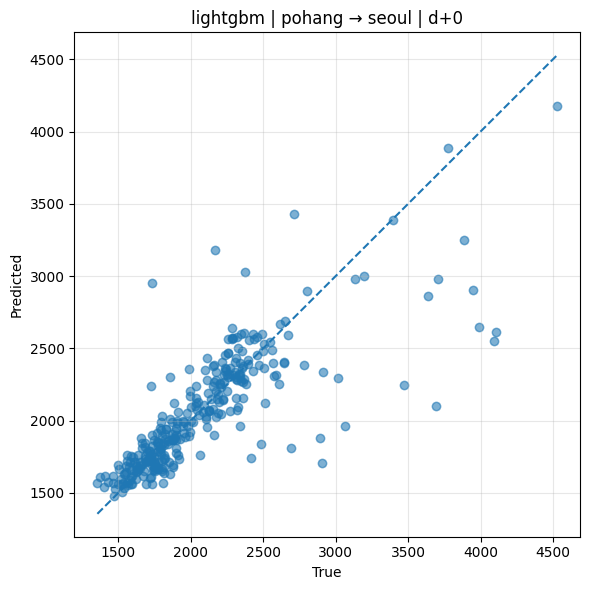

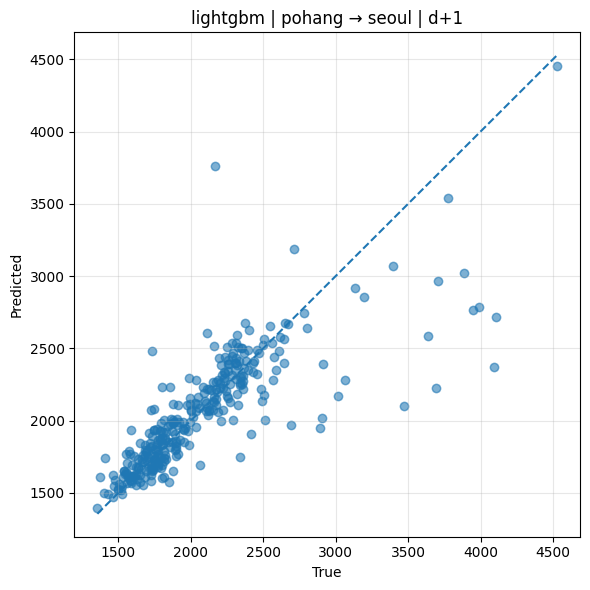

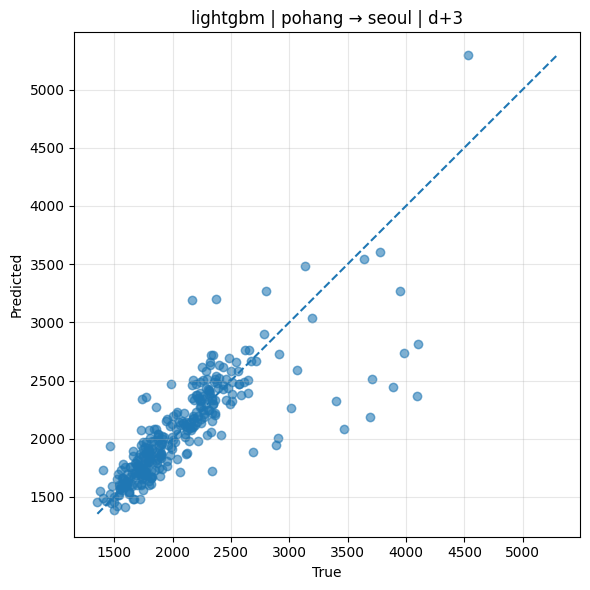

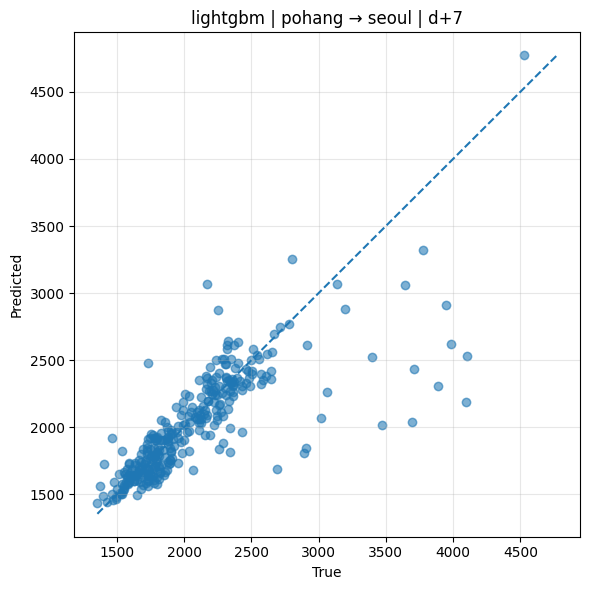

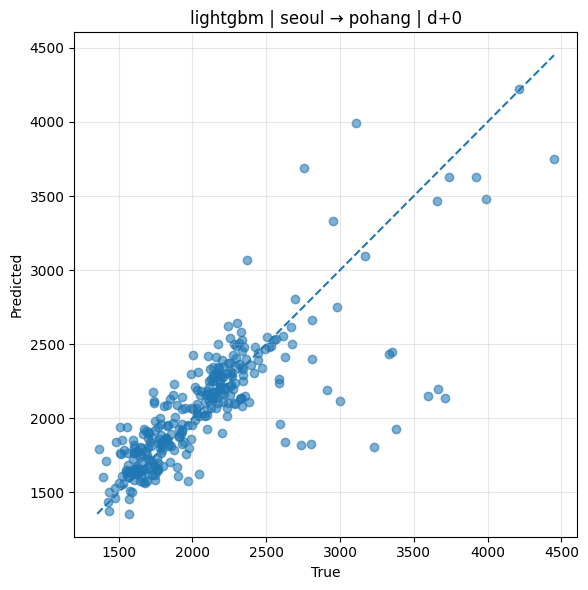

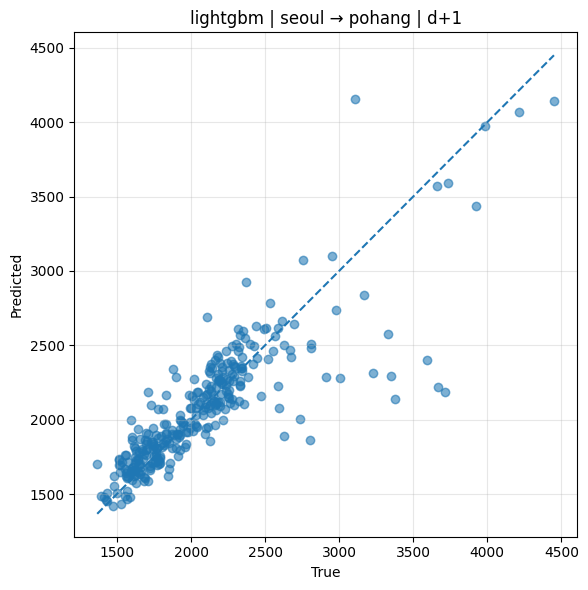

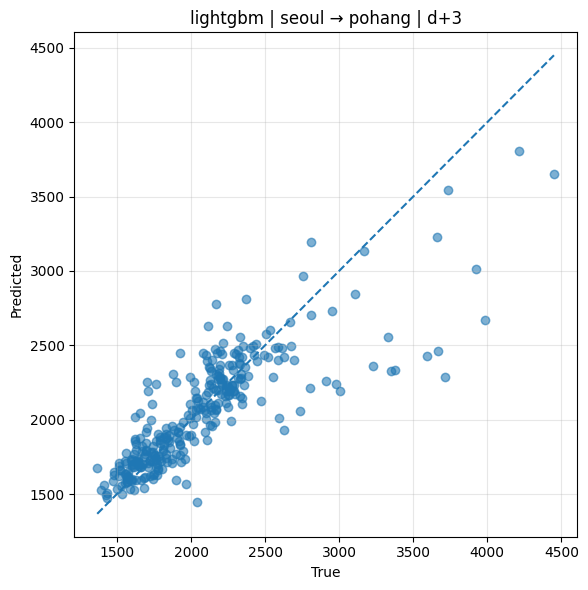

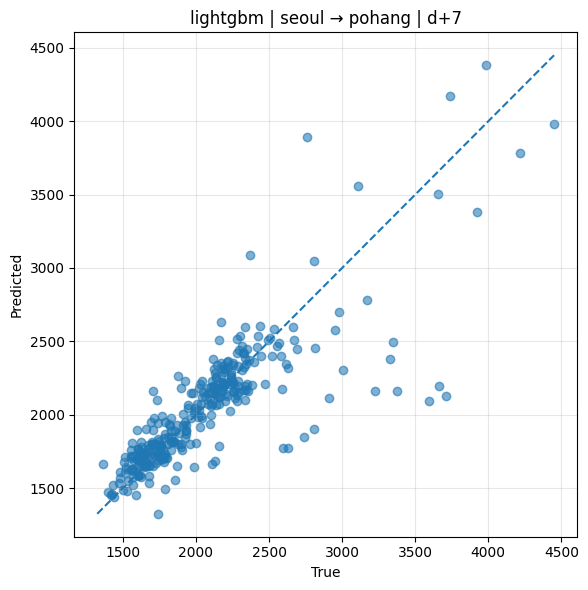

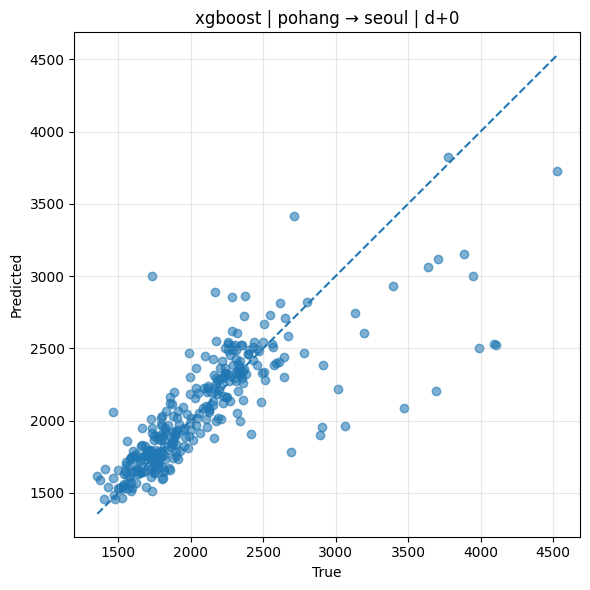

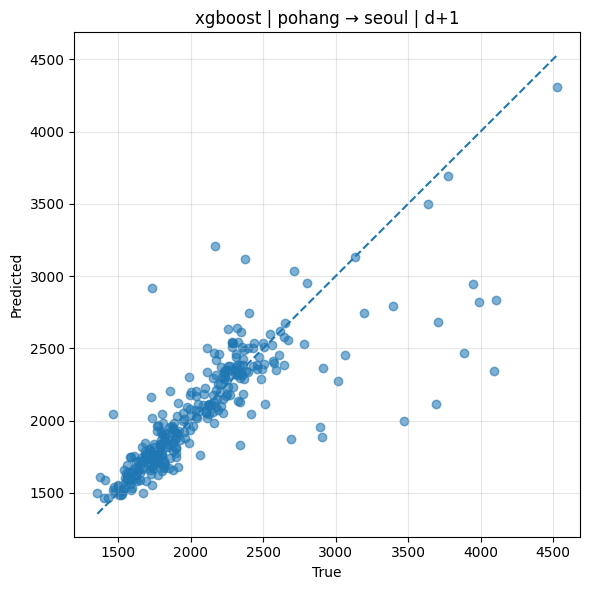

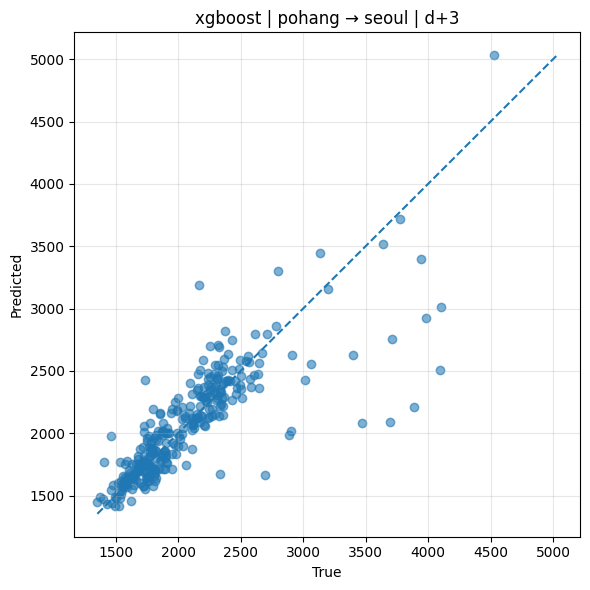

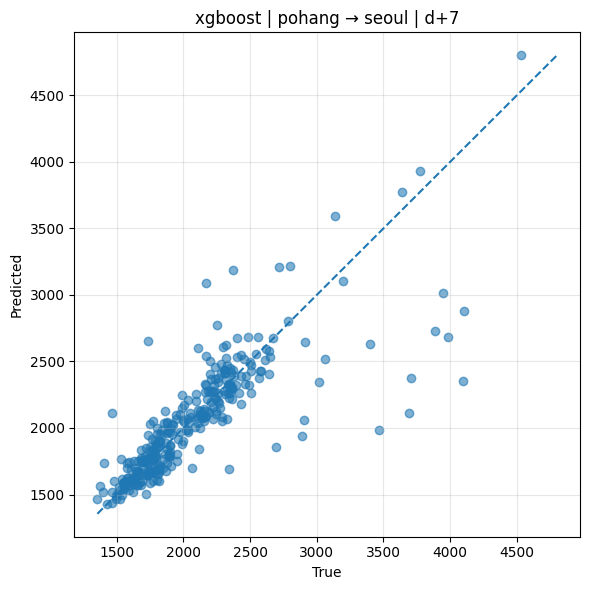

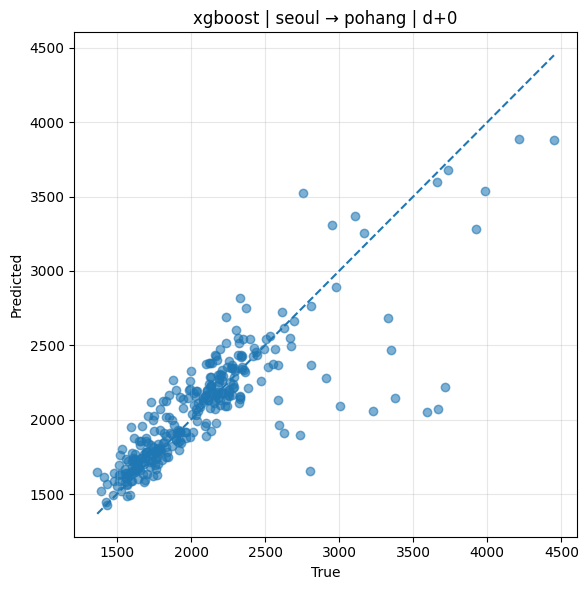

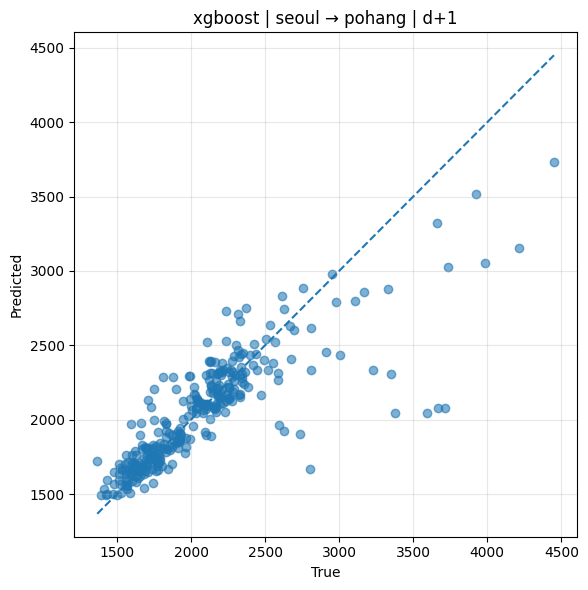

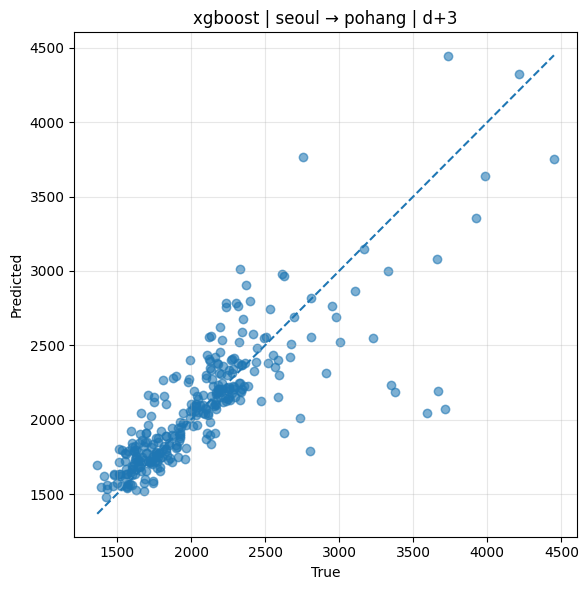

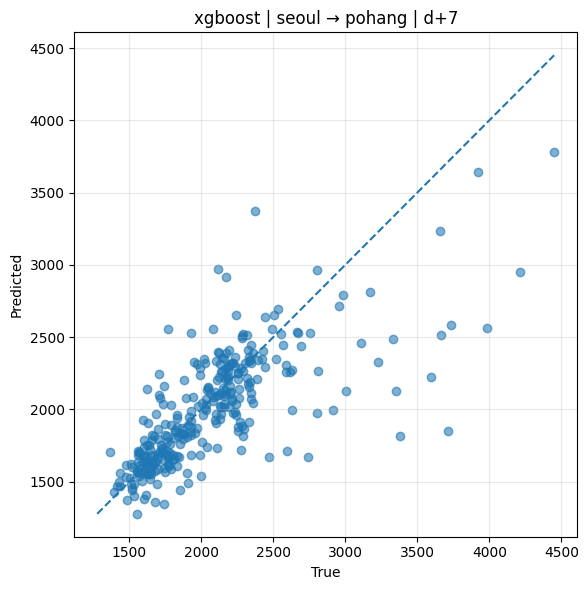

In [6]:
def plot_pred_vs_true(df, title):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(df['y_true'], df['y_pred'], alpha=0.35)
    mn = min(df['y_true'].min(), df['y_pred'].min())
    mx = max(df['y_true'].max(), df['y_pred'].max())
    ax.plot([mn, mx], [mn, mx], '--')
    ax.set_title(title)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if not pred_df.empty:
    for (model, origin, destination, horizon), g in pred_df.groupby(['model','origin','destination','horizon_days']):
        plot_pred_vs_true(g, f'{model} | {origin} → {destination} | d+{horizon}')

## 7. Residual distributions

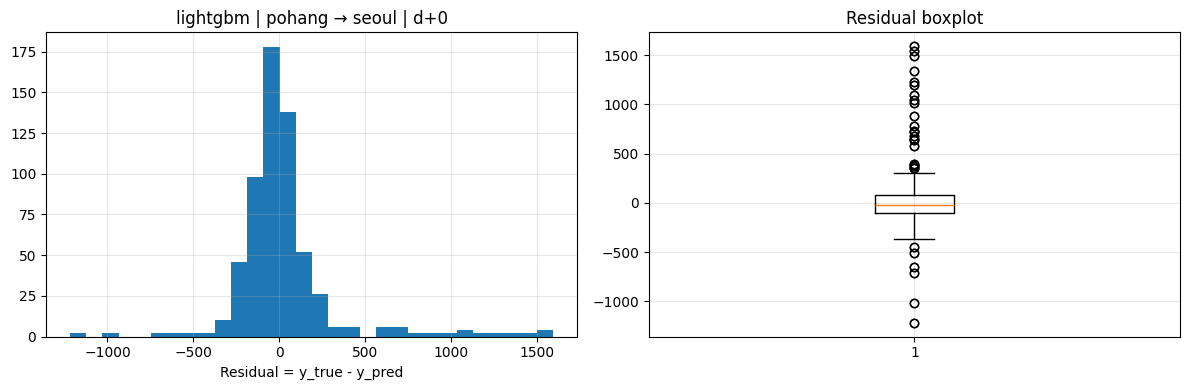

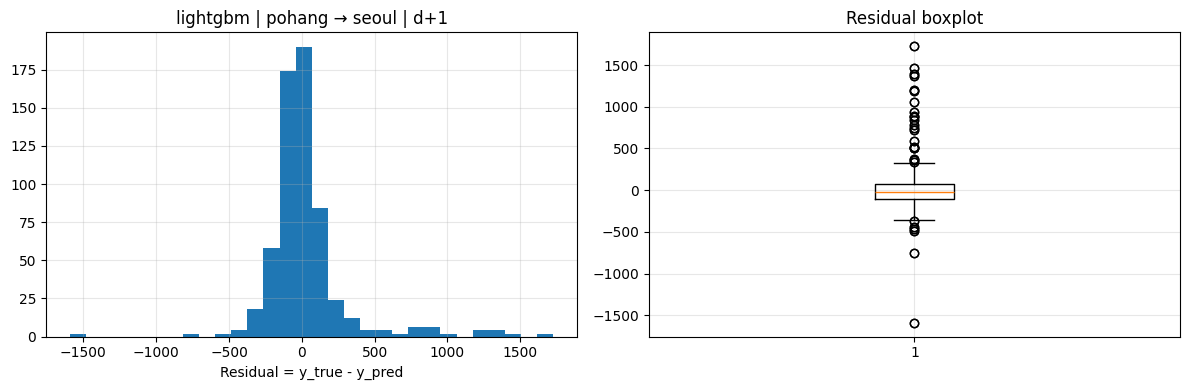

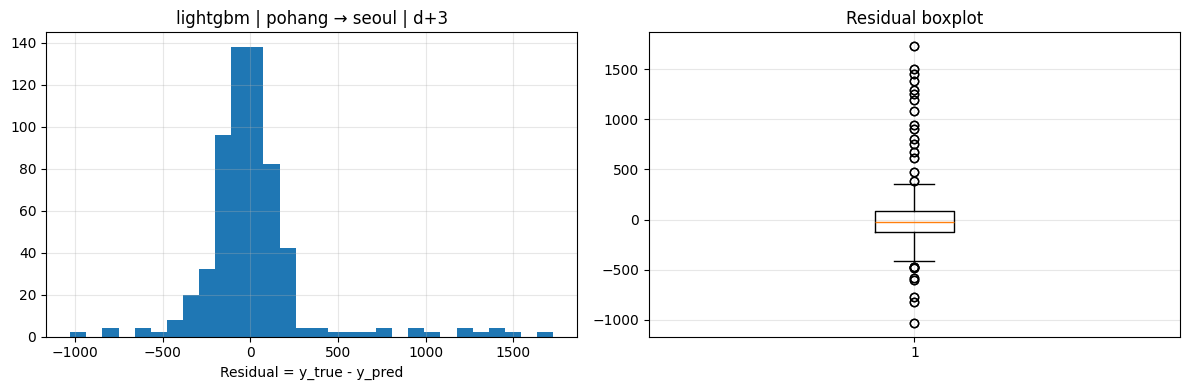

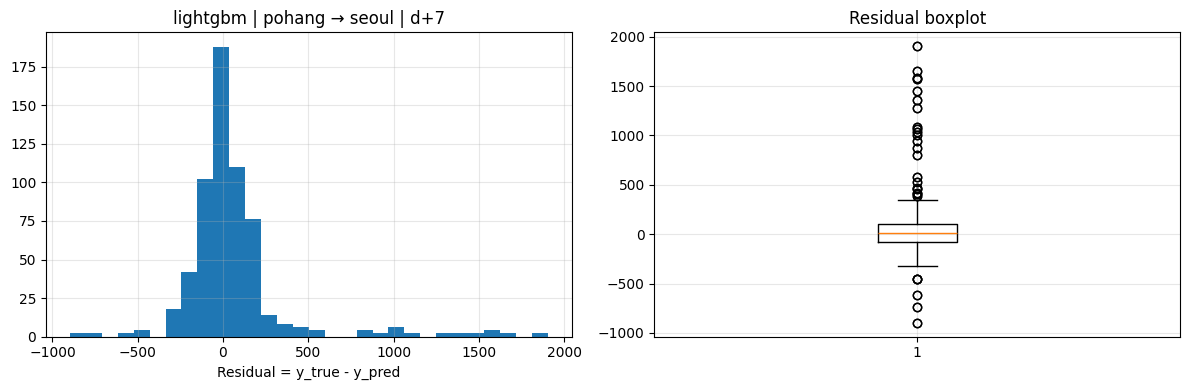

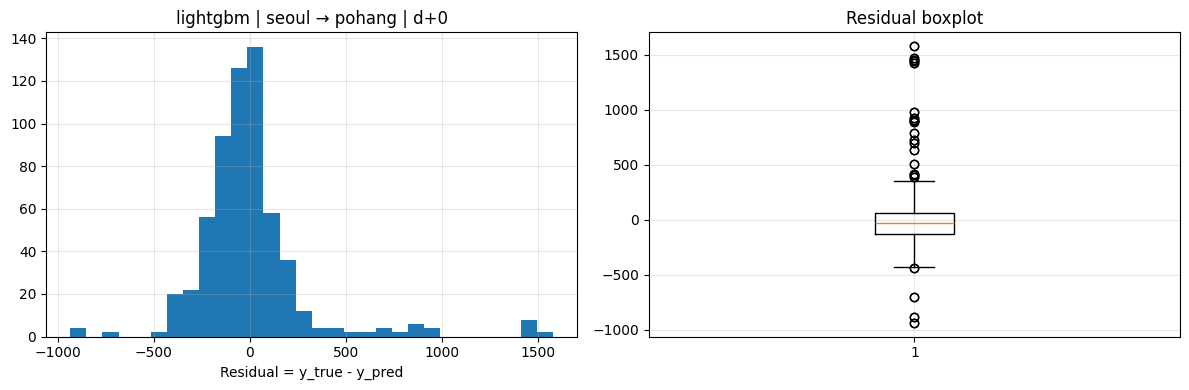

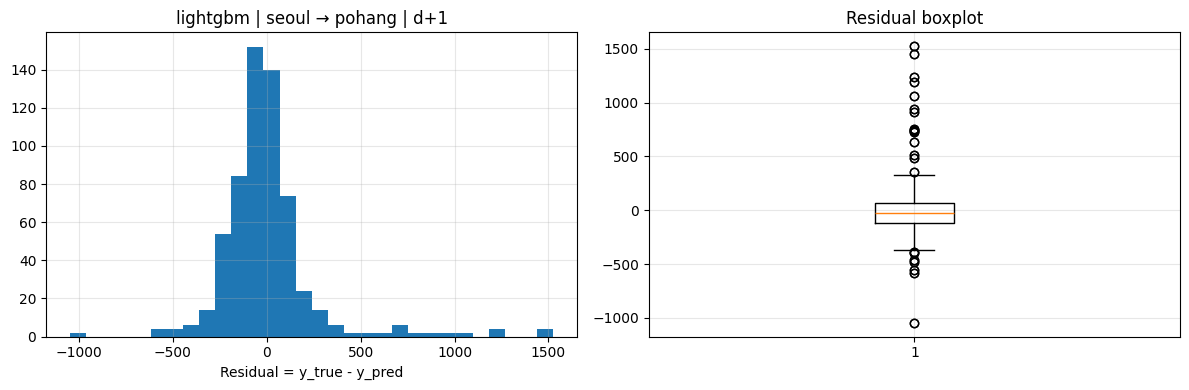

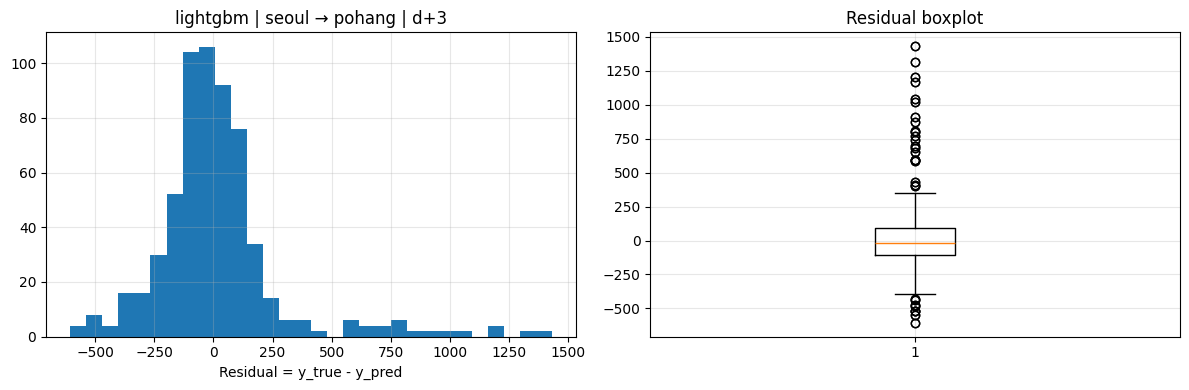

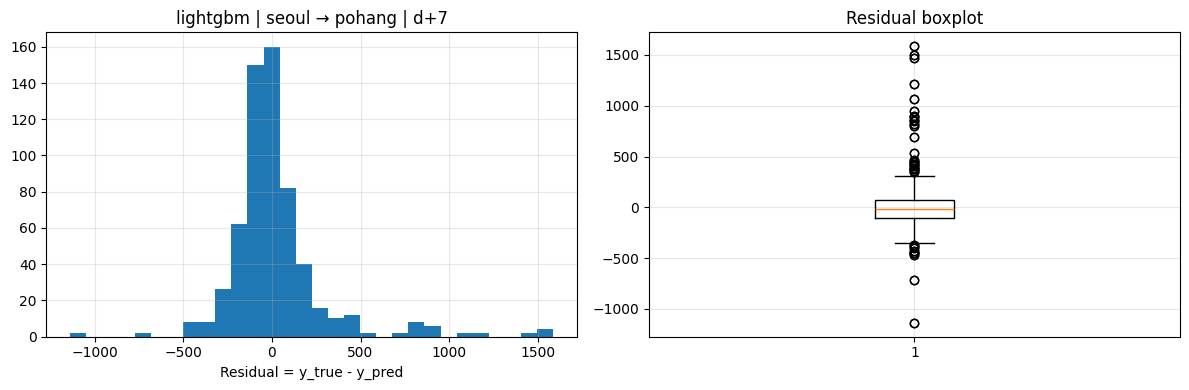

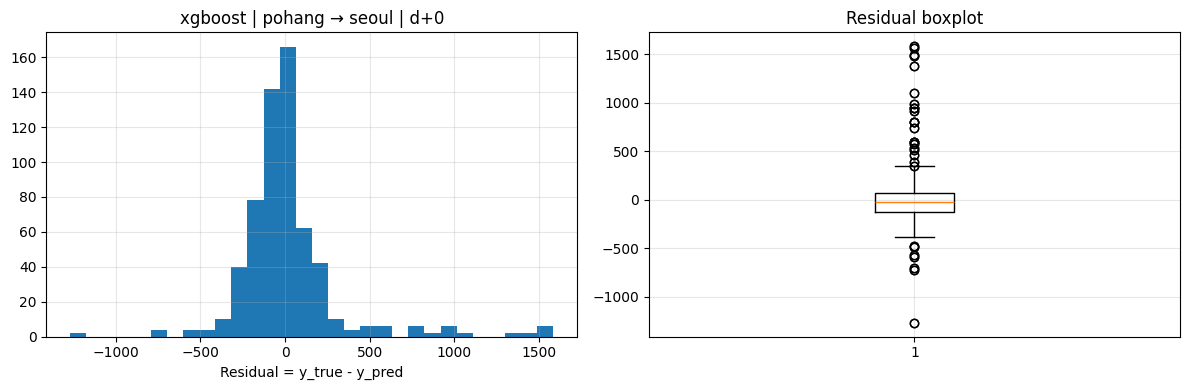

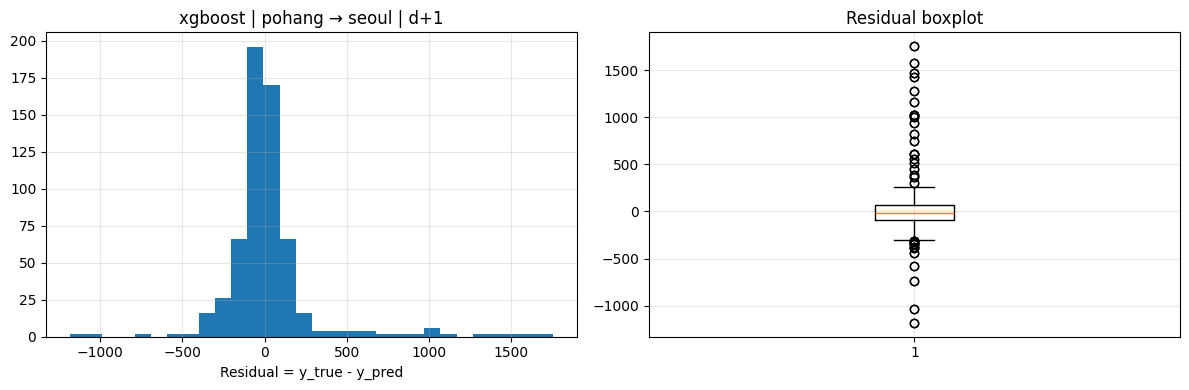

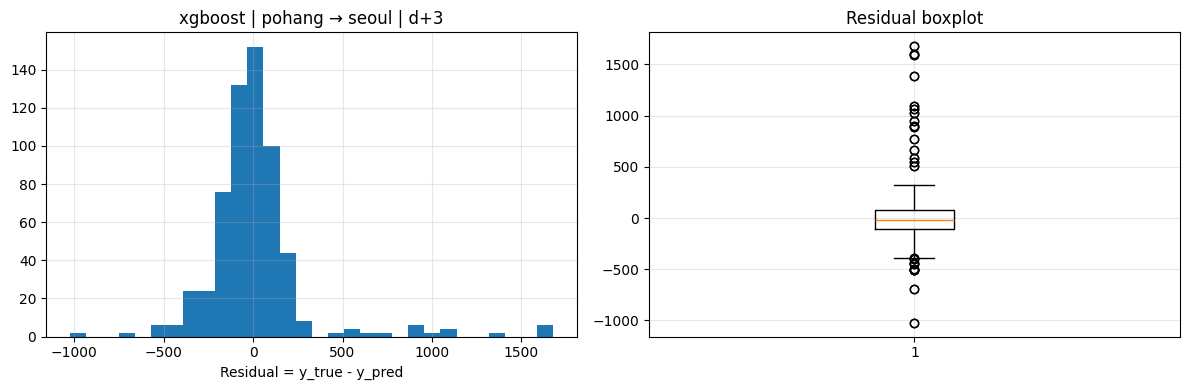

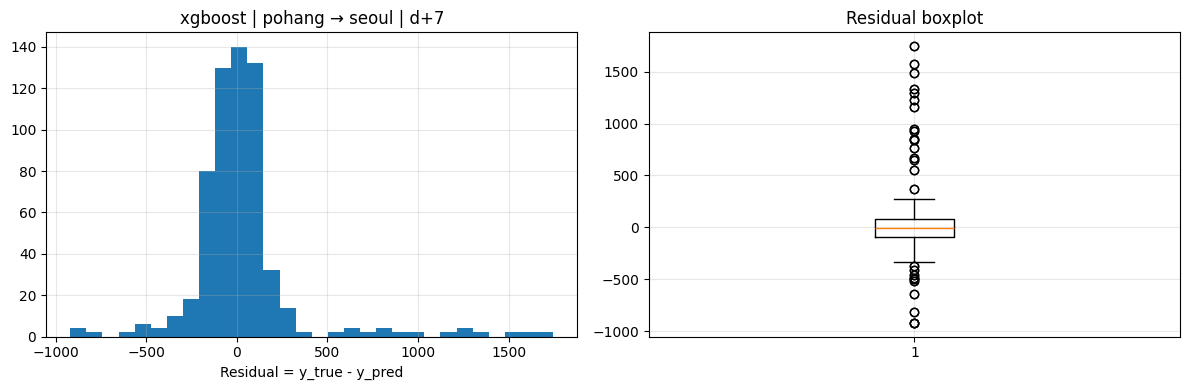

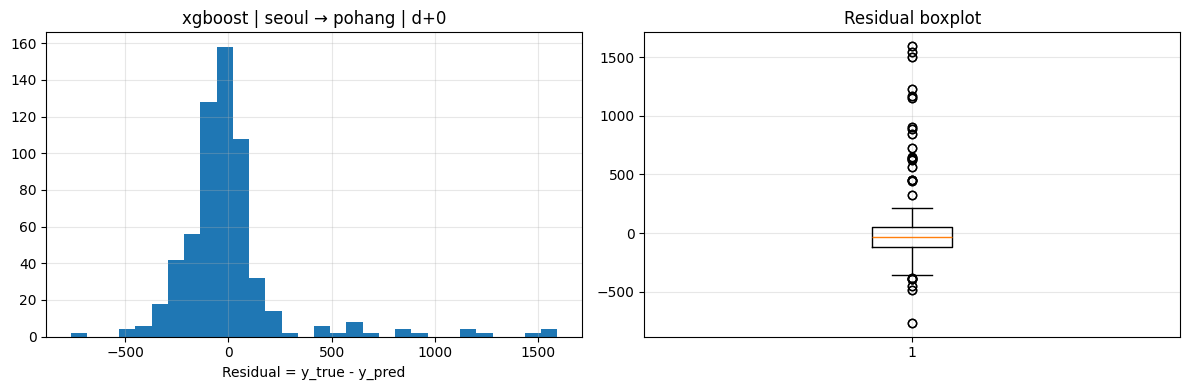

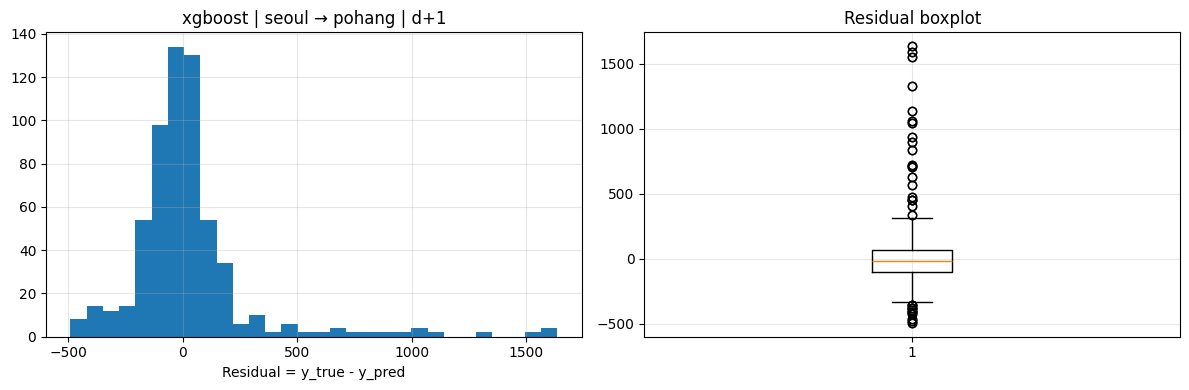

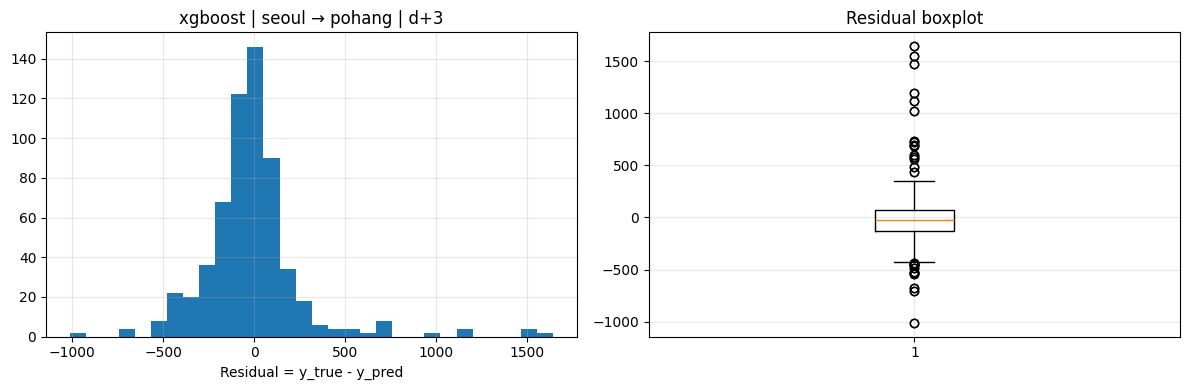

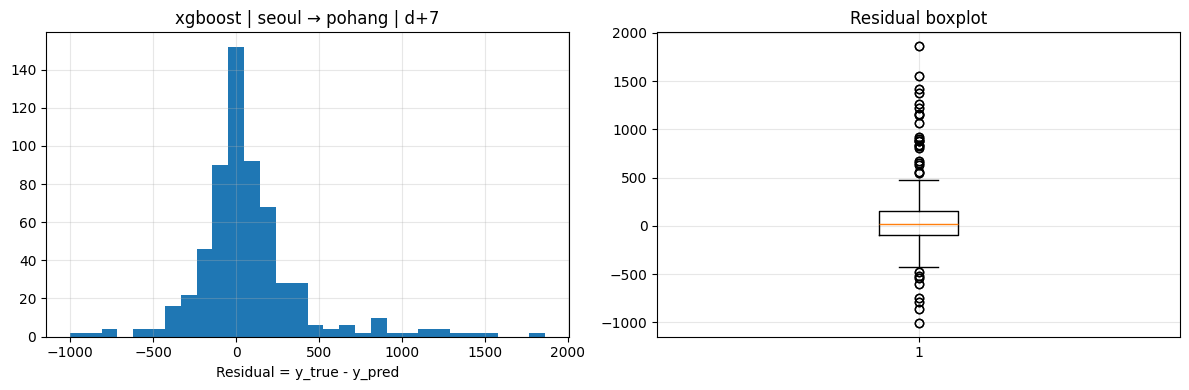

In [7]:
def plot_residual_hist(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].hist(df['residual'], bins=30)
    axes[0].set_title(title)
    axes[0].set_xlabel('Residual = y_true - y_pred')
    axes[0].grid(True, alpha=0.3)
    axes[1].boxplot(df['residual'], vert=True)
    axes[1].set_title('Residual boxplot')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if not pred_df.empty:
    for (model, origin, destination, horizon), g in pred_df.groupby(['model','origin','destination','horizon_days']):
        plot_residual_hist(g, f'{model} | {origin} → {destination} | d+{horizon}')

## 8. Biggest mistakes

In [8]:
if not pred_df.empty:
    worst = pred_df.sort_values('abs_error', ascending=False).head(20)
    display(worst[[c for c in ['model','origin','destination','horizon_days','y_true','y_pred','error','abs_error','source_file'] if c in worst.columns]])
else:
    worst = pd.DataFrame()

,model,origin,destination,horizon_days,y_true,y_pred,error,abs_error,source_file
1997,lightgbm,pohang,seoul,7,4096,2191.573302,1904.426698,1904.426698,lightgbm_pohang_to_seoul_d+7.csv
2300,lightgbm,pohang,seoul,7,4096,2191.573302,1904.426698,1904.426698,all_predictions.csv
9270,xgboost,seoul,pohang,7,3714,1851.191400,1862.808594,1862.808594,xgboost_seoul_to_pohang_d+7.csv
9573,xgboost,seoul,pohang,7,3714,1851.191400,1862.808594,1862.808594,all_predictions.csv
5936,xgboost,pohang,seoul,1,4096,2341.075000,1754.925049,1754.925049,all_predictions.csv
5633,xgboost,pohang,seoul,1,4096,2341.075000,1754.925049,1754.925049,xgboost_pohang_to_seoul_d+1.csv
6845,xgboost,pohang,seoul,7,4096,2350.634500,1745.365479,1745.365479,xgboost_pohang_to_seoul_d+7.csv
7148,xgboost,pohang,seoul,7,4096,2350.634500,1745.365479,1745.365479,all_predictions.csv
1391,lightgbm,pohang,seoul,3,4096,2368.413049,1727.586951,1727.586951,lightgbm_pohang_to_seoul_d+3.csv
1694,lightgbm,pohang,seoul,3,4096,2368.413049,1727.586951,1727.586951,all_predictions.csv


## 9. Error anatomy

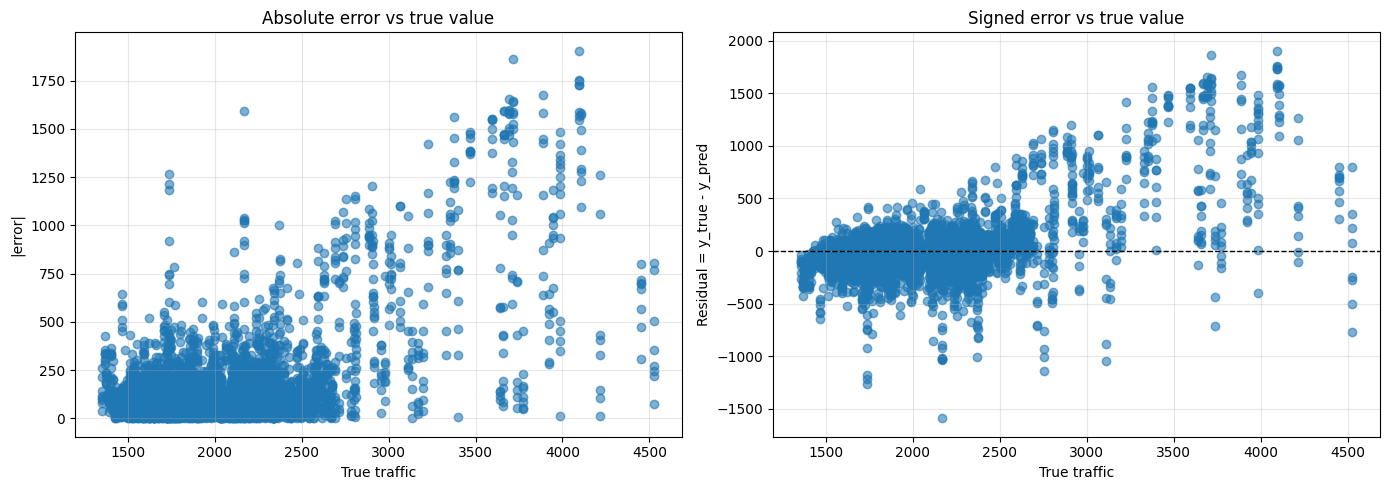

,true_bin,mean,median,count
0,"(1354.999, 1613.0]",100.984433,75.737701,1216
1,"(1613.0, 1729.0]",93.535260,73.757660,1216
2,"(1729.0, 1823.0]",115.263201,83.258456,1216
3,"(1823.0, 1989.5]",114.162577,90.388431,1200
4,"(1989.5, 2160.0]",116.099232,80.812500,1216
5,"(2160.0, 2281.0]",131.645612,96.403884,1216
6,"(2281.0, 2497.0]",146.955843,105.516479,1216
7,"(2497.0, 4528.0]",536.006544,349.958145,1200


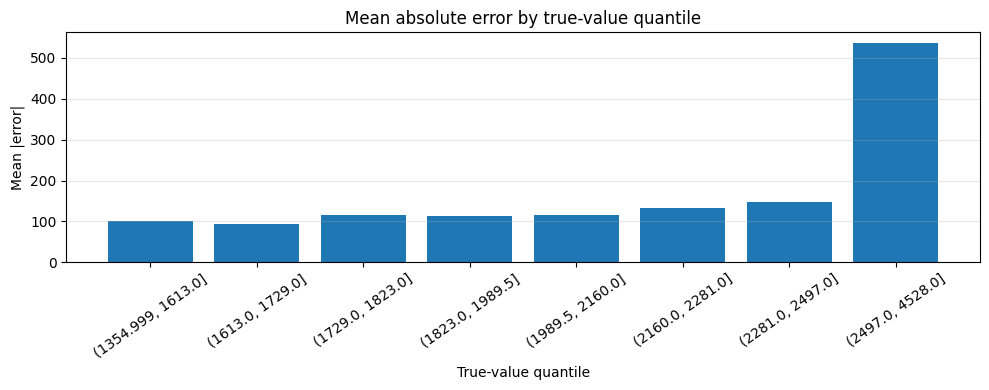

,model,origin,destination,horizon_days,over_rate,under_rate,mean_over_error,mean_under_error,mean_abs_error
0,lightgbm,pohang,seoul,0,0.432343,0.567657,222.243835,-127.836458,168.652849
1,lightgbm,pohang,seoul,1,0.429043,0.570957,218.032870,-124.210244,164.464176
2,lightgbm,pohang,seoul,3,0.452145,0.547855,205.074000,-147.470981,173.515910
3,lightgbm,pohang,seoul,7,0.524752,0.475248,218.481961,-114.904988,169.257261
4,lightgbm,seoul,pohang,0,0.429043,0.570957,209.106854,-149.700504,175.188377
5,lightgbm,seoul,pohang,1,0.415842,0.584158,188.654414,-131.386222,155.200718
6,lightgbm,seoul,pohang,3,0.448845,0.551155,211.818446,-136.126709,170.100558
7,lightgbm,seoul,pohang,7,0.432343,0.567657,214.501234,-124.034608,163.147242
8,xgboost,pohang,seoul,0,0.442244,0.557756,216.599271,-144.816458,176.561993
9,xgboost,pohang,seoul,1,0.478548,0.521452,189.202435,-127.976941,157.276270


In [9]:
if not pred_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(pred_df['y_true'], pred_df['abs_error'], alpha=0.35)
    axes[0].set_title('Absolute error vs true value')
    axes[0].set_xlabel('True traffic')
    axes[0].set_ylabel('|error|')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(pred_df['y_true'], pred_df['residual'], alpha=0.35)
    axes[1].axhline(0, linestyle='--', color='black', linewidth=1)
    axes[1].set_title('Signed error vs true value')
    axes[1].set_xlabel('True traffic')
    axes[1].set_ylabel('Residual = y_true - y_pred')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    bins = min(8, max(2, pred_df['y_true'].nunique()))
    binned = pred_df.copy()
    binned['true_bin'] = pd.qcut(binned['y_true'], q=bins, duplicates='drop')
    binned_summary = (
        binned.groupby('true_bin', observed=False)['abs_error']
        .agg(['mean', 'median', 'count'])
        .reset_index()
    )
    display(binned_summary)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(binned_summary['true_bin'].astype(str), binned_summary['mean'])
    ax.set_title('Mean absolute error by true-value quantile')
    ax.set_xlabel('True-value quantile')
    ax.set_ylabel('Mean |error|')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    signed = pred_df.copy()
    signed['direction'] = np.where(signed['error'] >= 0, 'overestimate', 'underestimate')
    sign_summary = (
        signed.groupby(['model', 'origin', 'destination', 'horizon_days'], dropna=False)
        .agg(
            over_rate=('direction', lambda s: (s == 'overestimate').mean()),
            under_rate=('direction', lambda s: (s == 'underestimate').mean()),
            mean_over_error=('error', lambda s: s[s >= 0].mean()),
            mean_under_error=('error', lambda s: s[s < 0].mean()),
            mean_abs_error=('abs_error', 'mean'),
        )
        .reset_index()
    )
    display(sign_summary.sort_values(['model', 'origin', 'destination', 'horizon_days']))
else:
    binned_summary = pd.DataFrame()
    sign_summary = pd.DataFrame()

## 10. Error by horizon

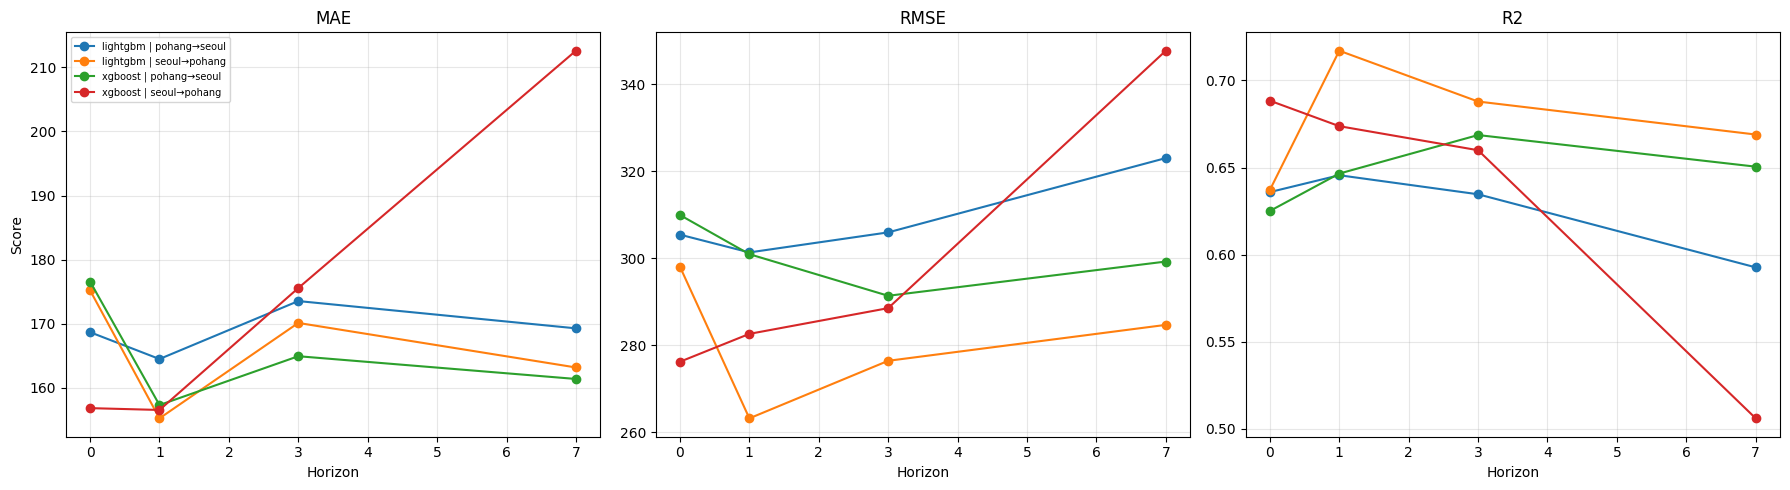

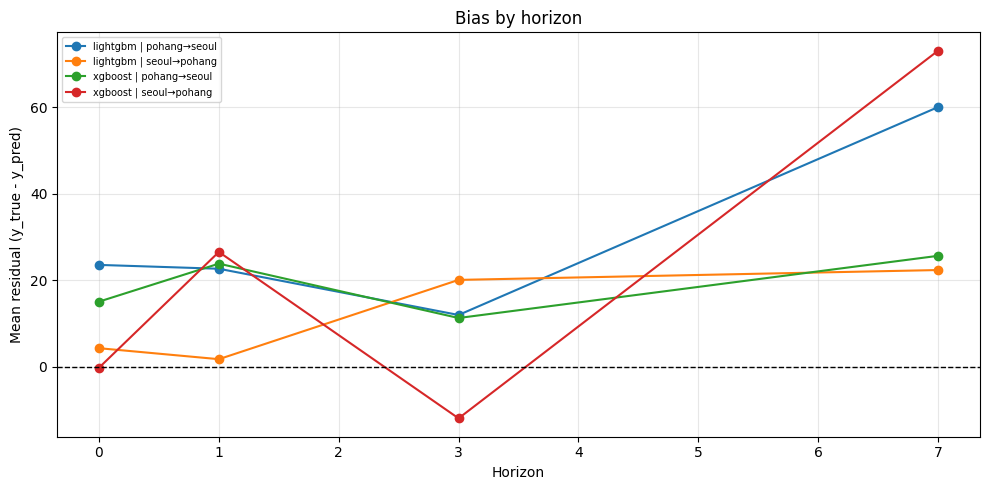

In [10]:
if not pred_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    err_summary = pred_df.groupby(['model','origin','destination','horizon_days'], dropna=False).apply(metrics_from_predictions).reset_index()
    for ax, metric in zip(axes, ['mae','rmse','r2']):
        for (model, origin, destination), sub in err_summary.groupby(['model','origin','destination']):
            sub = sub.sort_values('horizon_days')
            ax.plot(sub['horizon_days'], sub[metric], marker='o', label=f'{model} | {origin}→{destination}')
        ax.set_title(metric.upper())
        ax.set_xlabel('Horizon')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Score')
    axes[0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10,5))
    for (model, origin, destination), sub in err_summary.groupby(['model','origin','destination']):
        sub = sub.sort_values('horizon_days')
        ax.plot(sub['horizon_days'], sub['bias'], marker='o', label=f'{model} | {origin}→{destination}')
    ax.axhline(0, linestyle='--', color='black', linewidth=1)
    ax.set_title('Bias by horizon')
    ax.set_xlabel('Horizon')
    ax.set_ylabel('Mean residual (y_true - y_pred)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 11. Synthesis graphs

,model,test_mae,test_rmse,test_r2
0,lightgbm,167.440886,294.753614,0.652476
1,xgboost,170.194214,299.566521,0.639840


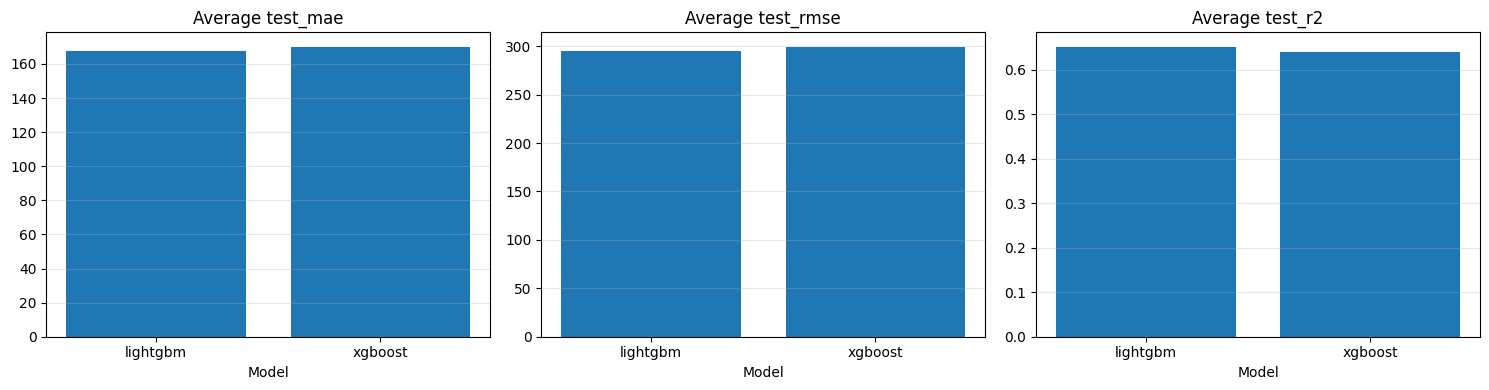

model                              lightgbm     xgboost
origin destination horizon_days                        
pohang seoul       0             168.652849  176.561981
                   1             164.464176  157.276276
                   3             173.515910  164.902298
                   7             169.257261  161.350235
seoul  pohang      0             175.188377  156.794525
                   1             155.200718  156.509644
                   3             170.100558  175.545715
                   7             163.147242  212.613037

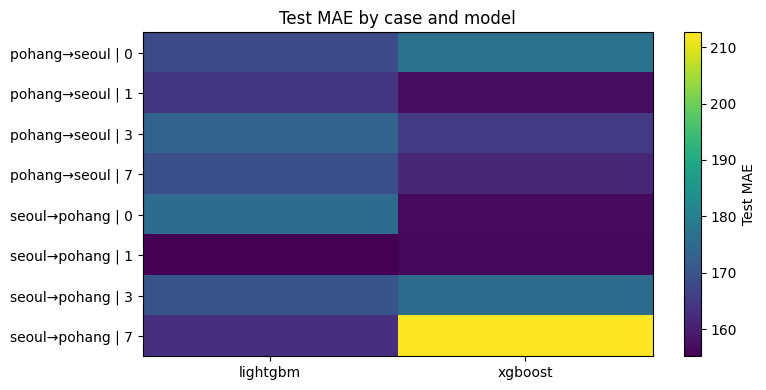

,best_case_count
model,
lightgbm,4
xgboost,4


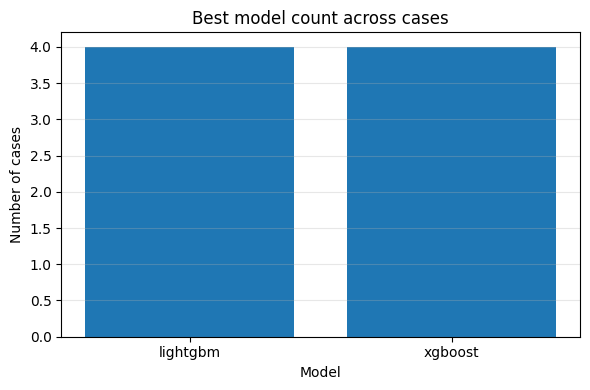

In [11]:
if not summary_df.empty:
    model_avg = (
        summary_df.groupby('model', dropna=False)[['test_mae', 'test_rmse', 'test_r2']]
        .mean()
        .reset_index()
    )
    display(model_avg)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, ['test_mae', 'test_rmse', 'test_r2']):
        ax.bar(model_avg['model'], model_avg[metric])
        ax.set_title(f'Average {metric}')
        ax.set_xlabel('Model')
        ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    pivot = summary_df.pivot_table(
        index=['origin', 'destination', 'horizon_days'],
        columns='model',
        values='test_mae',
        aggfunc='mean'
    )
    display(pivot)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(pivot))))
    im = ax.imshow(pivot.values, aspect='auto')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=0)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f'{o}→{d} | {h}' for (o, d, h) in pivot.index])
    ax.set_title('Test MAE by case and model')
    plt.colorbar(im, ax=ax, label='Test MAE')
    plt.tight_layout()
    plt.show()

if not best_per_case.empty:
    counts = best_per_case['model'].value_counts()
    display(counts.to_frame('best_case_count'))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title('Best model count across cases')
    ax.set_xlabel('Model')
    ax.set_ylabel('Number of cases')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()